# Course Campaign Analysis

Цель анализа — изучить связь конкретных маркетинговых кампаний
с продажами конкретных курсов.

Единица анализа:
**курс × маркетинговая кампания**.

Подход:
1. Связываем маркетинговые события с конкретными курсами через `candidate_courses`.
2. Не считаем обычные упоминания полноценной маркетинговой кампанией.
3. Близкие по времени маркетинговые события одного курса объединяем в одну кампанию.
4. Для каждой кампании сравниваем продажи курса:
   - до кампании;
   - во время кампании;
   - после кампании.
5. Не трактуем наблюдаемое изменение как доказанный причинный эффект:
   анализ показывает временную связь маркетинговой активности и продаж.

In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [49]:
SALES_PATH = Path("../data/raw/base.xlsx")
MARKETING_PATH = Path("../data/raw/marketing_history.xlsx")

print("Sales:", SALES_PATH.resolve())
print("Marketing:", MARKETING_PATH.resolve())

Sales: /Users/ulianaalekseeva/Postupashki/hackathon-postupashki/data/raw/base.xlsx
Marketing: /Users/ulianaalekseeva/Postupashki/hackathon-postupashki/data/raw/marketing_history.xlsx


In [50]:
sales = pd.read_excel(
    SALES_PATH,
    sheet_name="Данные"
)

sales = sales.rename(columns={
    "Номер студента": "student_id",
    "Сумма": "amount",
    "Курс": "course",
    "Время": "timestamp",
})

sales["timestamp"] = pd.to_datetime(
    sales["timestamp"],
    errors="coerce"
)

sales["amount"] = pd.to_numeric(
    sales["amount"],
    errors="coerce"
)

print("Строк продаж:", len(sales))
print(
    "Период продаж:",
    sales["timestamp"].min(),
    "—",
    sales["timestamp"].max()
)

sales.head()

Строк продаж: 795
Период продаж: 2026-08-04 09:08:31 — 2026-09-10 06:09:12


,student_id,amount,course,timestamp
0,437,"8,950.00",ML про,2026-08-04 09:08:31
1,437,"7,890.00",Аналитика старт,2026-08-04 09:35:00
2,443,"8,475.00",Линейная алгебра,2026-08-04 10:14:38
3,443,"8,475.00",Мат анализ,2026-08-04 10:14:38
4,430,"8,950.00",К ВУЗу,2026-08-04 13:38:06


In [51]:
marketing = pd.read_excel(
    MARKETING_PATH,
    sheet_name="marketing_events",
    header=2
)

# Удаляем технические пустые столбцы
marketing = marketing.loc[
    :,
    ~marketing.columns.astype(str).str.startswith("Unnamed")
].copy()

marketing["event_time"] = pd.to_datetime(
    marketing["event_time"],
    errors="coerce"
)

marketing["views"] = pd.to_numeric(
    marketing["views"],
    errors="coerce"
)

print("Маркетинговых событий:", len(marketing))
print(
    "Период маркетинга:",
    marketing["event_time"].min(),
    "—",
    marketing["event_time"].max()
)

marketing.head()

Маркетинговых событий: 210
Период маркетинга: 2026-07-01 18:10:49 — 2026-09-10 17:36:13


,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,views,reactions,cost_rub,data_source,confidence,collected_by,notes,channel_relationship,paid_status,raw_origin,raw_category,raw_period,raw_media,raw_forwarded_from,raw_links,raw_promo_candidate,raw_offer_flag,raw_discount_flag,raw_launch_flag,raw_lead_magnet_flag,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов,ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВсе подобное вы можете обсудить в комментариях под этим постом или в нашем чате.\n\n1. Стажировка Т-б...,internal,https://t.me/postypashki_old/1764,21200,42.00,NaN,Telegram,raw,Codex,Самые интересные события в ближайшее время. Все подобное вы можете обсудить в комментариях под этим постом или в нашем чате. 1. Стажировка Т-банк ...,internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-01T15:10:49+00:00,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент,NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой сделает работа в Сбере и Иннотехе: рабство, кастрация и принуждение к... Осторожно, факты вас шокирую...",internal,https://t.me/postypashki_old/1765,17500,50.00,NaN,Telegram,raw,Codex,"В новом ролике обсудим, что с вашей психикой сделает работа в Сбере и Иннотехе: рабство, кастрация и принуждение к... Осторожно, факты вас шокирую...",internal,unknown,telegram_internal,Прочий контент,Предыстория,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,False,2026-07-02T15:31:22+00:00,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку в Т-банк\n\nВ честь этого события объявляем скидку до 5 июля на наши карьерные курсы старт.\n➡️ Запи...,internal,https://t.me/postypashki_old/1767,18600,25.00,NaN,Telegram,raw,Codex,❗️ Завтра заканчивается донабор на стажировку в Т-банк В честь этого события объявляем скидку до 5 июля на наши карьерные курсы старт. ➡️ Записать...,internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,1.00,1.00,0.00,0.00,NaN,False,2026-07-04T09:03:55+00:00,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов,ML старт,NaN,postypashki_old/1768,"Академия Авито и Буткем Авито \n\nСегодня прошел первый этап отбора в Академию Авито. За час мы решили все задачи и разбор на нашем курсе, благода...",internal,https://t.me/postypashki_old/1768,20400,26.00,NaN,Telegram,raw,Codex,"Академия Авито и Буткем Авито Сегодня прошел первый этап отбора в Академию Авито. За час мы решили все задачи и разбор на нашем курсе, благодаря к...",internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-04T12:35:53+00:00,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Промо со скидкой,ML старт,NaN,postypashki_old/1770,"Как затащить МЛ собеседование в 2026 году \n\nВ вебинаре разобрали, что сегодня ждут от начинающего ML-специалиста: какие темы проверяют на технич...",internal,https://t.me/postypashki_old/1770,19000,36.00,NaN,Telegram,raw,Codex,"Как затащить МЛ собеседование в 2026 году В вебинаре разобрали, что сегодня ждут от начинающего ML-специалиста: какие темы проверяют на технически...",internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,0.00,1.00,0.00,0.00,NaN,False,2026-07-05T13:51:14+00:00,NaN,single_course,START,ML старт,ml,ML старт


In [52]:
required_marketing_columns = [
    "event_id",
    "event_time",
    "source_channel",
    "activity_type",
    "external_or_internal",
    "product_scope",
    "product_line",
    "candidate_courses",
    "views",
]

missing_columns = [
    col
    for col in required_marketing_columns
    if col not in marketing.columns
]

if missing_columns:
    raise ValueError(
        f"В Marketing History отсутствуют колонки: {missing_columns}"
    )

print("Все необходимые колонки найдены.")

Все необходимые колонки найдены.


In [53]:
COURSE_MAPPING = {
    "AI агенты": "AI-агенты про",
    "АВ тестам": "А/В-тесты",
    "Data science": "Data Science",
}

sales["course_analysis"] = (
    sales["course"]
    .replace(COURSE_MAPPING)
    .str.strip()
)

In [54]:
course_events_all = marketing[
    [
        "event_id",
        "event_time",
        "source_channel",
        "activity_type",
        "external_or_internal",
        "product_scope",
        "product_line",
        "candidate_courses",
        "views",
    ]
].copy()

# Оставляем только события, которые можно связать
# с конкретным продуктом/продуктами
course_events_all = course_events_all[
    course_events_all["candidate_courses"].notna()
].copy()

# Общебрендовые события пока не используем
# в анализе отдельных курсов
course_events_all = course_events_all[
    course_events_all["candidate_courses"] != "ALL_PORTFOLIO"
].copy()

course_events_all["course_analysis"] = (
    course_events_all["candidate_courses"]
    .astype(str)
    .str.split(r"\s*\|\s*")
)

course_events_all = (
    course_events_all
    .explode("course_analysis")
    .reset_index(drop=True)
)

course_events_all["course_analysis"] = (
    course_events_all["course_analysis"]
    .replace(COURSE_MAPPING)
    .str.strip()
)

course_events_all["event_date"] = (
    course_events_all["event_time"]
    .dt.floor("D")
)

# Одно событие не должно дважды попасть
# к одному и тому же курсу
course_events_all = course_events_all.drop_duplicates(
    subset=["event_id", "course_analysis"]
)

course_events_all.head(15)

,event_id,event_time,source_channel,activity_type,external_or_internal,product_scope,product_line,candidate_courses,views,course_analysis,event_date
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов,internal,multiple_courses,START,ML старт | Data science,21200,ML старт,2026-07-01
1,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов,internal,multiple_courses,START,ML старт | Data science,21200,Data Science,2026-07-01
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,18600,Аналитика старт,2026-07-04
3,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,18600,Алгоритмы старт,2026-07-04
4,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,18600,Backend старт,2026-07-04
5,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,18600,ML старт,2026-07-04
6,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов,internal,single_course,START,ML старт,20400,ML старт,2026-07-04
7,INT-1770,2026-07-05 16:51:14,@postypashki_old,Промо со скидкой,internal,single_course,START,ML старт,19000,ML старт,2026-07-05
8,INT-1771,2026-07-05 20:03:02,@postypashki_old,Контент с предложением курсов,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,21700,Аналитика старт,2026-07-05
9,INT-1771,2026-07-05 20:03:02,@postypashki_old,Контент с предложением курсов,internal,product_line,START,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,21700,Алгоритмы старт,2026-07-05


In [55]:
sales_courses = set(
    sales["course_analysis"]
    .dropna()
    .unique()
)

marketing_courses = set(
    course_events_all["course_analysis"]
    .dropna()
    .unique()
)

print("Есть и в sales, и в marketing:")
print(sorted(sales_courses & marketing_courses))

print("\nЕсть в marketing, но нет в sales:")
print(sorted(marketing_courses - sales_courses))

Есть и в sales, и в marketing:
['AI-агенты про', 'Backend про', 'Backend старт', 'Data Science', 'ML про', 'ML старт', 'А/В-тесты', 'Алгоритмы про', 'Алгоритмы старт', 'Аналитика про', 'Аналитика старт']

Есть в marketing, но нет в sales:
[]


In [56]:
activity_text = (
    course_events_all["activity_type"]
    .fillna("")
    .str.lower()
)

marketing_keywords = (
    "промо|"
    "скид|"
    "предлож|"
    "запуск|"
    "набор|"
    "лид-магнит|"
    "реклам"
)

course_events_all["is_marketing_signal"] = (
    activity_text.str.contains(
        marketing_keywords,
        regex=True
    )
)

course_events_all[
    [
        "activity_type",
        "is_marketing_signal"
    ]
].value_counts()

activity_type                    is_marketing_signal
Контент с предложением курсов    True                   154
Промо со скидкой                 True                   100
Запуск / набор                   True                    56
Контент с упоминанием            False                   45
Прочий контент                   False                    3
Бесплатное событие / лид-магнит  True                     1
Name: count, dtype: int64

In [57]:
course_marketing_events = (
    course_events_all[
        course_events_all["is_marketing_signal"]
    ]
    .copy()
)

print(
    "Всего связей событие × курс:",
    len(course_events_all)
)

print(
    "Из них маркетинговых:",
    len(course_marketing_events)
)

course_marketing_events[
    "activity_type"
].value_counts()

Всего связей событие × курс: 359
Из них маркетинговых: 311


activity_type
Контент с предложением курсов      154
Промо со скидкой                   100
Запуск / набор                      56
Бесплатное событие / лид-магнит      1
Name: count, dtype: int64

In [58]:
GAP_DAYS = 2
MAX_CAMPAIGN_SPAN_DAYS = 5

In [59]:
def assign_campaign_numbers(
    df,
    gap_days=2,
    max_span_days=5
):
    parts = []

    for course, group in df.groupby(
        "course_analysis",
        sort=False
    ):
        group = (
            group
            .sort_values(["event_date", "event_time"])
            .copy()
        )

        campaign_num = 0
        campaign_start = None
        previous_date = None

        campaign_numbers = []

        for current_date in group["event_date"]:

            if previous_date is None:
                campaign_num += 1
                campaign_start = current_date

            else:
                gap = (
                    current_date - previous_date
                ).days

                span = (
                    current_date - campaign_start
                ).days

                if (
                    gap > gap_days
                    or span >= max_span_days
                ):
                    campaign_num += 1
                    campaign_start = current_date

            campaign_numbers.append(
                campaign_num
            )

            previous_date = current_date

        group["campaign_num"] = campaign_numbers

        parts.append(group)

    return pd.concat(
        parts,
        ignore_index=True
    )

In [60]:
course_marketing_events = assign_campaign_numbers(
    course_marketing_events,
    gap_days=GAP_DAYS,
    max_span_days=MAX_CAMPAIGN_SPAN_DAYS
)

course_marketing_events["campaign_id"] = (
    course_marketing_events["course_analysis"]
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
    + "_"
    + course_marketing_events["campaign_num"]
      .astype(str)
)

course_marketing_events[
    [
        "course_analysis",
        "event_date",
        "activity_type",
        "campaign_id"
    ]
].head(30)

,course_analysis,event_date,activity_type,campaign_id
0,ML старт,2026-07-01,Контент с предложением курсов,ML_старт_1
1,ML старт,2026-07-04,Промо со скидкой,ML_старт_2
2,ML старт,2026-07-04,Контент с предложением курсов,ML_старт_2
3,ML старт,2026-07-05,Промо со скидкой,ML_старт_2
4,ML старт,2026-07-05,Контент с предложением курсов,ML_старт_2
5,ML старт,2026-07-18,Запуск / набор,ML_старт_3
6,ML старт,2026-07-18,Запуск / набор,ML_старт_3
7,ML старт,2026-07-18,Запуск / набор,ML_старт_3
8,ML старт,2026-07-19,Контент с предложением курсов,ML_старт_3
9,ML старт,2026-07-19,Запуск / набор,ML_старт_3


In [61]:
campaigns = (
    course_marketing_events
    .groupby(
        [
            "course_analysis",
            "campaign_id"
        ],
        as_index=False
    )
    .agg(
        campaign_start=(
            "event_date",
            "min"
        ),
        campaign_end=(
            "event_date",
            "max"
        ),
        events_count=(
            "event_id",
            "nunique"
        ),
        channels_count=(
            "source_channel",
            "nunique"
        ),
        total_views=(
            "views",
            "sum"
        ),
        activity_types=(
            "activity_type",
            lambda x:
                " | ".join(
                    sorted(
                        set(x.dropna())
                    )
                )
        ),
        channels=(
            "source_channel",
            lambda x:
                " | ".join(
                    sorted(
                        set(x.dropna())
                    )
                )
        )
    )
    .rename(
        columns={
            "course_analysis": "course"
        }
    )
)

campaigns["campaign_days"] = (
    campaigns["campaign_end"]
    - campaigns["campaign_start"]
).dt.days + 1

campaigns = campaigns.sort_values(
    [
        "course",
        "campaign_start"
    ]
).reset_index(drop=True)

campaigns.head(30)

,course,campaign_id,campaign_start,campaign_end,events_count,channels_count,total_views,activity_types,channels,campaign_days
0,AI-агенты про,AI-агенты_про_1,2026-07-27,2026-07-27,1,1,22700,Контент с предложением курсов,@postypashki_old,1
1,AI-агенты про,AI-агенты_про_2,2026-08-05,2026-08-05,1,1,8440,Контент с предложением курсов,@chad_protocol,1
2,AI-агенты про,AI-агенты_про_3,2026-08-11,2026-08-11,1,1,18000,Контент с предложением курсов,@postypashki_old,1
3,AI-агенты про,AI-агенты_про_4,2026-08-22,2026-08-26,8,5,78160,Запуск / набор | Контент с предложением курсов,@algoses | @chad_protocol | @postypashki_mems | @postypashki_old | @zadachi_ds,5
4,AI-агенты про,AI-агенты_про_5,2026-08-27,2026-08-31,6,4,52143,Запуск / набор | Контент с предложением курсов,@ProdAnalysis | @chad_protocol | @codeof_art | @postypashki_old,5
5,AI-агенты про,AI-агенты_про_6,2026-09-01,2026-09-05,14,8,78317,Контент с предложением курсов | Промо со скидкой,@ProdAnalysis | @algoses | @chad_protocol | @codeof_art | @matesha_shad | @postypashki_mems | @postypashki_old | @zadachi_ds,5
6,AI-агенты про,AI-агенты_про_7,2026-09-06,2026-09-07,5,4,33032,Контент с предложением курсов | Промо со скидкой,@ProdAnalysis | @matesha_shad | @postypashki_old | @zadachi_ds,2
7,Backend про,Backend_про_1,2026-07-27,2026-07-27,1,1,22700,Контент с предложением курсов,@postypashki_old,1
8,Backend про,Backend_про_2,2026-08-05,2026-08-05,1,1,8440,Контент с предложением курсов,@chad_protocol,1
9,Backend про,Backend_про_3,2026-08-11,2026-08-11,1,1,18000,Контент с предложением курсов,@postypashki_old,1


In [62]:
campaigns[
    [
        "course",
        "campaign_start",
        "campaign_end",
        "campaign_days",
        "events_count",
        "channels_count",
        "activity_types"
    ]
].sort_values(
    "campaign_days",
    ascending=False
).head(20)

,course,campaign_start,campaign_end,campaign_days,events_count,channels_count,activity_types
33,ML старт,2026-07-23,2026-07-27,5,3,2,Контент с предложением курсов | Промо со скидкой
12,Backend про,2026-09-01,2026-09-05,5,12,6,Контент с предложением курсов | Промо со скидкой
44,Алгоритмы про,2026-09-01,2026-09-05,5,13,8,Контент с предложением курсов | Промо со скидкой
43,Алгоритмы про,2026-08-27,2026-08-31,5,6,4,Запуск / набор | Контент с предложением курсов
42,Алгоритмы про,2026-08-22,2026-08-26,5,7,6,Запуск / набор | Контент с предложением курсов | Промо со скидкой
49,Алгоритмы старт,2026-07-23,2026-07-27,5,3,2,Контент с предложением курсов | Промо со скидкой
28,ML про,2026-09-01,2026-09-05,5,12,7,Контент с предложением курсов | Промо со скидкой
27,ML про,2026-08-27,2026-08-31,5,6,4,Запуск / набор | Контент с предложением курсов
26,ML про,2026-08-22,2026-08-26,5,7,5,Запуск / набор | Контент с предложением курсов
57,Аналитика про,2026-08-30,2026-09-03,5,13,7,Контент с предложением курсов


In [63]:
sales["date"] = (
    sales["timestamp"]
    .dt.floor("D")
)

sales_daily_raw = (
    sales
    .groupby(
        [
            "date",
            "course_analysis"
        ],
        as_index=False
    )
    .agg(
        purchases=(
            "student_id",
            "size"
        ),
        buyers=(
            "student_id",
            "nunique"
        )
    )
    .rename(
        columns={
            "course_analysis": "course"
        }
    )
)

sales_daily_raw.head()

,date,course,purchases,buyers
0,2026-08-04,Backend старт,1,1
1,2026-08-04,Data Science,1,1
2,2026-08-04,ML про,2,2
3,2026-08-04,ML старт,1,1
4,2026-08-04,Аналитика старт,1,1


In [35]:
sales_daily[
    sales_daily["course"] == "Аналитика старт"
].sort_values("date").head(20)

,date,course,purchases,buyers
7,2026-08-04,Аналитика старт,1,1
15,2026-08-05,Аналитика старт,0,0
23,2026-08-06,Аналитика старт,0,0
31,2026-08-07,Аналитика старт,0,0
39,2026-08-08,Аналитика старт,7,7
47,2026-08-09,Аналитика старт,17,17
55,2026-08-10,Аналитика старт,11,11
63,2026-08-11,Аналитика старт,2,2
71,2026-08-12,Аналитика старт,4,4
79,2026-08-13,Аналитика старт,0,0


In [64]:
relevant_courses = sorted(
    set(campaigns["course"])
    & set(sales_daily_raw["course"])
)

all_dates = pd.date_range(
    sales["date"].min(),
    sales["date"].max(),
    freq="D"
)

full_index = pd.MultiIndex.from_product(
    [
        all_dates,
        relevant_courses
    ],
    names=[
        "date",
        "course"
    ]
)

sales_daily = (
    sales_daily_raw
    .set_index(
        ["date", "course"]
    )
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)

sales_daily.head()

,date,course,purchases,buyers
0,2026-08-04,AI-агенты про,0,0
1,2026-08-04,Backend про,0,0
2,2026-08-04,Backend старт,1,1
3,2026-08-04,Data Science,1,1
4,2026-08-04,ML про,2,2


In [65]:
BASELINE_DAYS = 7
AFTER_DAYS = 3

In [66]:
sales_start = sales_daily["date"].min()
sales_end = sales_daily["date"].max()

results = []

for _, campaign in campaigns.iterrows():

    course = campaign["course"]
    start = campaign["campaign_start"]
    end = campaign["campaign_end"]

    baseline_start = (
        start
        - pd.Timedelta(
            days=BASELINE_DAYS
        )
    )

    after_end = (
        end
        + pd.Timedelta(
            days=AFTER_DAYS
        )
    )

    has_full_window = (
        baseline_start >= sales_start
        and after_end <= sales_end
    )

    if not has_full_window:
        continue

    course_sales = sales_daily[
        sales_daily["course"] == course
    ]

    before = course_sales[
        (course_sales["date"] >= baseline_start)
        & (course_sales["date"] < start)
    ]

    during = course_sales[
        (course_sales["date"] >= start)
        & (course_sales["date"] <= end)
    ]

    after = course_sales[
        (course_sales["date"] > end)
        & (course_sales["date"] <= after_end)
    ]

    results.append({
        "course": course,
        "campaign_id": campaign["campaign_id"],

        "campaign_start": start,
        "campaign_end": end,

        "campaign_days":
            campaign["campaign_days"],

        "events_count":
            campaign["events_count"],

        "channels_count":
            campaign["channels_count"],

        "total_views":
            campaign["total_views"],

        "activity_types":
            campaign["activity_types"],

        "before_purchases_per_day":
            before["purchases"].mean(),

        "during_purchases_per_day":
            during["purchases"].mean(),

        "after_purchases_per_day":
            after["purchases"].mean(),

        "before_buyers_per_day":
            before["buyers"].mean(),

        "during_buyers_per_day":
            during["buyers"].mean(),

        "after_buyers_per_day":
            after["buyers"].mean(),
    })

campaign_results = pd.DataFrame(results)

print(
    "Кампаний с полным окном данных:",
    len(campaign_results)
)

campaign_results.head()

Кампаний с полным окном данных: 29


,course,campaign_id,campaign_start,campaign_end,campaign_days,events_count,channels_count,total_views,activity_types,before_purchases_per_day,during_purchases_per_day,after_purchases_per_day,before_buyers_per_day,during_buyers_per_day,after_buyers_per_day
0,AI-агенты про,AI-агенты_про_3,2026-08-11,2026-08-11,1,1,1,18000,Контент с предложением курсов,0.00,0.00,0.00,0.00,0.00,0.00
1,AI-агенты про,AI-агенты_про_4,2026-08-22,2026-08-26,5,8,5,78160,Запуск / набор | Контент с предложением курсов,0.00,7.20,3.00,0.00,7.20,3.00
2,AI-агенты про,AI-агенты_про_5,2026-08-27,2026-08-31,5,6,4,52143,Запуск / набор | Контент с предложением курсов,5.14,4.40,2.00,5.14,4.40,2.00
3,AI-агенты про,AI-агенты_про_6,2026-09-01,2026-09-05,5,14,8,78317,Контент с предложением курсов | Промо со скидкой,4.71,2.40,6.00,4.71,2.40,6.00
4,AI-агенты про,AI-агенты_про_7,2026-09-06,2026-09-07,2,5,4,33032,Контент с предложением курсов | Промо со скидкой,3.57,8.50,1.33,3.57,8.50,1.33


In [67]:
campaign_results["delta_during"] = (
    campaign_results[
        "during_purchases_per_day"
    ]
    - campaign_results[
        "before_purchases_per_day"
    ]
)

campaign_results["delta_after"] = (
    campaign_results[
        "after_purchases_per_day"
    ]
    - campaign_results[
        "before_purchases_per_day"
    ]
)

campaign_results[
    "uplift_during_pct"
] = np.where(
    campaign_results[
        "before_purchases_per_day"
    ] > 0,

    (
        campaign_results[
            "during_purchases_per_day"
        ]
        / campaign_results[
            "before_purchases_per_day"
        ]
        - 1
    ) * 100,

    np.nan
)

campaign_results[
    "uplift_after_pct"
] = np.where(
    campaign_results[
        "before_purchases_per_day"
    ] > 0,

    (
        campaign_results[
            "after_purchases_per_day"
        ]
        / campaign_results[
            "before_purchases_per_day"
        ]
        - 1
    ) * 100,

    np.nan
)

In [68]:
campaign_results[
    [
        "course",
        "campaign_start",
        "campaign_end",
        "events_count",
        "channels_count",
        "before_purchases_per_day",
        "during_purchases_per_day",
        "after_purchases_per_day",
        "delta_during",
        "uplift_during_pct"
    ]
].sort_values(
    "delta_during",
    ascending=False
).head(20)

,course,campaign_start,campaign_end,events_count,channels_count,before_purchases_per_day,during_purchases_per_day,after_purchases_per_day,delta_during,uplift_during_pct
1,AI-агенты про,2026-08-22,2026-08-26,8,5,0.00,7.20,3.00,7.20,NaN
4,AI-агенты про,2026-09-06,2026-09-07,5,4,3.57,8.50,1.33,4.93,138.00
14,ML про,2026-09-01,2026-09-05,12,7,2.43,6.80,5.67,4.37,180.00
8,Backend про,2026-09-01,2026-09-05,12,6,1.14,4.60,2.33,3.46,302.50
12,ML про,2026-08-22,2026-08-26,7,5,0.00,3.40,2.67,3.40,NaN
6,Backend про,2026-08-22,2026-08-26,8,6,0.14,2.80,0.67,2.66,"1,860.00"
15,ML про,2026-09-06,2026-09-07,5,4,5.57,8.00,1.00,2.43,43.59
26,Аналитика про,2026-08-30,2026-09-03,13,7,2.86,5.00,9.33,2.14,75.00
20,Алгоритмы про,2026-08-22,2026-08-26,7,6,0.00,2.00,0.00,2.00,NaN
22,Алгоритмы про,2026-09-01,2026-09-05,13,8,0.71,2.20,1.67,1.49,208.00


In [69]:
campaigns[
    [
        "course",
        "campaign_start",
        "campaign_end",
        "campaign_days",
        "events_count"
    ]
].sort_values(
    "campaign_days",
    ascending=False
).head(20)

,course,campaign_start,campaign_end,campaign_days,events_count
33,ML старт,2026-07-23,2026-07-27,5,3
12,Backend про,2026-09-01,2026-09-05,5,12
44,Алгоритмы про,2026-09-01,2026-09-05,5,13
43,Алгоритмы про,2026-08-27,2026-08-31,5,6
42,Алгоритмы про,2026-08-22,2026-08-26,5,7
49,Алгоритмы старт,2026-07-23,2026-07-27,5,3
28,ML про,2026-09-01,2026-09-05,5,12
27,ML про,2026-08-27,2026-08-31,5,6
26,ML про,2026-08-22,2026-08-26,5,7
57,Аналитика про,2026-08-30,2026-09-03,5,13


In [70]:
campaign_events = marketing[
    [
        "event_id",
        "event_time",
        "source_channel",
        "activity_type",
        "product_scope",
        "product_line",
        "candidate_courses",
        "views",
    ]
].copy()

campaign_events["event_time"] = pd.to_datetime(
    campaign_events["event_time"],
    errors="coerce"
)

campaign_events["event_date"] = (
    campaign_events["event_time"]
    .dt.floor("D")
)

activity_text = (
    campaign_events["activity_type"]
    .fillna("")
    .str.lower()
)

campaign_events = campaign_events[
    activity_text.str.contains(
        "промо|скид|предлож|запуск|набор|лид-магнит|реклам",
        regex=True
    )
].copy()

In [71]:
marketing_days = (
    campaign_events
    .groupby("event_date", as_index=False)
    .agg(
        events_count=("event_id", "nunique"),
        channels_count=("source_channel", "nunique"),
        total_views=("views", "sum"),
        activity_types=(
            "activity_type",
            lambda x: " | ".join(sorted(set(x.dropna())))
        ),
        product_lines=(
            "product_line",
            lambda x: " | ".join(
                sorted(set(x.dropna().astype(str)))
            )
        )
    )
)

marketing_days.sort_values("event_date")

,event_date,events_count,channels_count,total_views,activity_types,product_lines
0,2026-07-01,1,1,21200,Контент с предложением курсов,START
1,2026-07-03,1,1,2650,Бесплатное событие / лид-магнит,
2,2026-07-04,2,1,39000,Контент с предложением курсов | Промо со скидкой,START
3,2026-07-05,2,1,40700,Контент с предложением курсов | Промо со скидкой,START
4,2026-07-10,1,1,17600,Контент с предложением курсов,
5,2026-07-11,2,1,33200,Бесплатное событие / лид-магнит | Контент с предложением курсов,START
6,2026-07-12,1,1,17200,Промо со скидкой,START
7,2026-07-13,1,1,16400,Контент с предложением курсов,START
8,2026-07-14,2,1,45600,Бесплатное событие / лид-магнит | Контент с предложением курсов,START
9,2026-07-15,1,1,2590,Бесплатное событие / лид-магнит,


In [72]:
marketing_days.sort_values(
    ["events_count", "total_views"],
    ascending=False
).head(20)

,event_date,events_count,channels_count,total_views,activity_types,product_lines
29,2026-08-10,13,8,77205,Промо со скидкой,START
49,2026-09-07,12,7,56850,Бесплатное событие / лид-магнит | Контент с предложением курсов,PRO
35,2026-08-23,6,5,55255,Контент с предложением курсов | Промо со скидкой,PRO
48,2026-09-06,6,3,42665,Бесплатное событие / лид-магнит | Контент с предложением курсов | Промо со скидкой,PRO
27,2026-08-08,6,6,30624,Внешняя реклама | Промо со скидкой,START
46,2026-09-03,6,6,25559,Контент с предложением курсов,PRO | START | PRO
45,2026-09-02,5,5,24507,Контент с предложением курсов,PRO
24,2026-08-02,4,4,39711,Бесплатное событие / лид-магнит,
34,2026-08-22,3,3,43910,Запуск / набор | Контент с предложением курсов,PRO
28,2026-08-09,3,2,39300,Промо со скидкой,START


In [73]:
campaign_events["product_line_clean"] = (
    campaign_events["product_line"]
    .fillna("")
    .astype(str)
    .str.replace("START | PRO | PRO", "START | PRO", regex=False)
    .str.replace("PRO | START | PRO", "START | PRO", regex=False)
    .str.strip()
)

line_daily = (
    campaign_events
    .groupby(
        ["event_date", "product_line_clean"],
        as_index=False
    )
    .agg(
        events_count=("event_id", "nunique"),
        channels_count=("source_channel", "nunique"),
        total_views=("views", "sum"),
        activity_types=(
            "activity_type",
            lambda x: " | ".join(sorted(set(x.dropna())))
        )
    )
)

line_daily = line_daily[
    line_daily["product_line_clean"] != ""
].copy()

line_daily.sort_values(
    ["product_line_clean", "event_date"]
)

,event_date,product_line_clean,events_count,channels_count,total_views,activity_types
31,2026-08-05,PRO,1,1,8440,Контент с предложением курсов
37,2026-08-11,PRO,1,1,18000,Контент с предложением курсов
41,2026-08-22,PRO,3,3,43910,Запуск / набор | Контент с предложением курсов
42,2026-08-23,PRO,6,5,55255,Контент с предложением курсов | Промо со скидкой
43,2026-08-24,PRO,2,2,8540,Контент с предложением курсов
44,2026-08-25,PRO,2,2,3920,Запуск / набор
46,2026-08-26,PRO,2,2,5400,Запуск / набор
47,2026-08-27,PRO,1,1,741,Запуск / набор
49,2026-08-29,PRO,3,3,26412,Запуск / набор | Контент с предложением курсов
51,2026-08-30,PRO,1,1,4690,Контент с предложением курсов


In [74]:
line_daily["is_core_day"] = (
    (line_daily["events_count"] >= 3)
    |
    line_daily["activity_types"].str.contains(
        "Запуск|скид",
        case=False,
        na=False
    )
)

core_days = line_daily[
    line_daily["is_core_day"]
].copy()

core_days[
    [
        "event_date",
        "product_line_clean",
        "events_count",
        "channels_count",
        "total_views",
        "activity_types"
    ]
].sort_values(
    ["product_line_clean", "event_date"]
)

,event_date,product_line_clean,events_count,channels_count,total_views,activity_types
41,2026-08-22,PRO,3,3,43910,Запуск / набор | Контент с предложением курсов
42,2026-08-23,PRO,6,5,55255,Контент с предложением курсов | Промо со скидкой
44,2026-08-25,PRO,2,2,3920,Запуск / набор
46,2026-08-26,PRO,2,2,5400,Запуск / набор
47,2026-08-27,PRO,1,1,741,Запуск / набор
49,2026-08-29,PRO,3,3,26412,Запуск / набор | Контент с предложением курсов
56,2026-09-02,PRO,5,5,24507,Контент с предложением курсов
57,2026-09-03,PRO,5,5,24570,Контент с предложением курсов
59,2026-09-05,PRO,2,2,5100,Промо со скидкой
61,2026-09-06,PRO,3,2,27002,Контент с предложением курсов | Промо со скидкой


In [75]:
core_days = core_days.sort_values(
    ["product_line_clean", "event_date"]
).copy()

core_days["gap_days"] = (
    core_days
    .groupby("product_line_clean")["event_date"]
    .diff()
    .dt.days
)

core_days["new_wave"] = (
    core_days["gap_days"].isna()
    | (core_days["gap_days"] > 2)
)

core_days["wave_num"] = (
    core_days
    .groupby("product_line_clean")["new_wave"]
    .cumsum()
)

core_days["wave_id"] = (
    core_days["product_line_clean"]
    .str.replace(" ", "_", regex=False)
    + "_wave_"
    + core_days["wave_num"].astype(str)
)

In [76]:
marketing_waves = (
    core_days
    .groupby(
        ["product_line_clean", "wave_id"],
        as_index=False
    )
    .agg(
        wave_start=("event_date", "min"),
        wave_end=("event_date", "max"),
        active_days=("event_date", "nunique"),
        events_count=("events_count", "sum"),
        channels_max=("channels_count", "max"),
        total_views=("total_views", "sum"),
        activity_types=(
            "activity_types",
            lambda x: " | ".join(sorted(set(x)))
        )
    )
)

marketing_waves["wave_days"] = (
    marketing_waves["wave_end"]
    - marketing_waves["wave_start"]
).dt.days + 1

marketing_waves.sort_values(
    ["product_line_clean", "wave_start"]
)

,product_line_clean,wave_id,wave_start,wave_end,active_days,events_count,channels_max,total_views,activity_types,wave_days
0,PRO,PRO_wave_1,2026-08-22,2026-08-29,6,17,5,135638,Запуск / набор | Запуск / набор | Контент с предложением курсов | Контент с предложением курсов | Промо со скидкой,8
1,PRO,PRO_wave_2,2026-09-02,2026-09-07,5,20,5,93549,Контент с предложением курсов | Контент с предложением курсов | Промо со скидкой | Промо со скидкой,6
2,START,START_wave_1,2026-07-04,2026-07-05,2,4,1,79700,Контент с предложением курсов | Промо со скидкой,2
3,START,START_wave_2,2026-07-12,2026-07-12,1,1,1,17200,Промо со скидкой,1
4,START,START_wave_3,2026-07-18,2026-07-20,3,7,3,38816,Запуск / набор | Запуск / набор | Контент с предложением курсов,3
5,START,START_wave_4,2026-07-25,2026-07-25,1,1,1,2050,Промо со скидкой,1
6,START,START_wave_5,2026-08-08,2026-08-10,3,21,8,131729,Промо со скидкой,3


In [77]:
wave_events = []

for _, wave in marketing_waves.iterrows():

    line = wave["product_line_clean"]
    start = wave["wave_start"]
    end = wave["wave_end"]

    current = campaign_events[
        (campaign_events["product_line_clean"] == line)
        & (campaign_events["event_date"] >= start)
        & (campaign_events["event_date"] <= end)
    ].copy()

    current["wave_id"] = wave["wave_id"]

    wave_events.append(current)

wave_events = pd.concat(
    wave_events,
    ignore_index=True
)

wave_events.head()

,event_id,event_time,source_channel,activity_type,product_scope,product_line,candidate_courses,views,event_date,product_line_clean,wave_id
0,INT-1859,2026-08-22 13:19:48,@postypashki_old,Запуск / набор,multiple_courses,PRO,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,35200,2026-08-22,PRO,PRO_wave_1
1,INT-1860,2026-08-23 11:51:41,@postypashki_old,Контент с предложением курсов,single_course,PRO,AI-агенты про | А/В-тесты,20400,2026-08-23,PRO,PRO_wave_1
2,INT-1863,2026-08-23 19:20:03,@postypashki_old,Контент с предложением курсов,single_course,PRO,Backend про,21300,2026-08-23,PRO,PRO_wave_1
3,INT-1872,2026-08-29 21:58:58,@postypashki_old,Контент с предложением курсов,multiple_courses,PRO,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,20100,2026-08-29,PRO,PRO_wave_1
4,EXT-60,2026-08-22 19:14:53,@ProdAnalysis,Контент с предложением курсов,single_course,PRO,Аналитика про,4110,2026-08-22,PRO,PRO_wave_1


In [78]:
wave_summary = (
    wave_events
    .groupby(
        ["wave_id", "product_line_clean"],
        as_index=False
    )
    .agg(
        wave_start=("event_date", "min"),
        wave_end=("event_date", "max"),

        events_count=("event_id", "nunique"),
        active_days=("event_date", "nunique"),
        channels_count=("source_channel", "nunique"),
        total_views=("views", "sum"),

        activity_types=(
            "activity_type",
            lambda x: " | ".join(
                sorted(set(x.dropna()))
            )
        ),

        channels=(
            "source_channel",
            lambda x: " | ".join(
                sorted(set(x.dropna()))
            )
        )
    )
)

wave_summary["wave_days"] = (
    wave_summary["wave_end"]
    - wave_summary["wave_start"]
).dt.days + 1

wave_summary.sort_values("wave_start")

,wave_id,product_line_clean,wave_start,wave_end,events_count,active_days,channels_count,total_views,activity_types,channels,wave_days
2,START_wave_1,START,2026-07-04,2026-07-05,4,2,1,79700,Контент с предложением курсов | Промо со скидкой,@postypashki_old,2
3,START_wave_2,START,2026-07-12,2026-07-12,1,1,1,17200,Промо со скидкой,@postypashki_old,1
4,START_wave_3,START,2026-07-18,2026-07-20,7,3,7,38816,Запуск / набор | Контент с предложением курсов,@algoses | @chad_protocol | @codeof_art | @matesha_shad | @postypashki_mems | @postypashki_old | @zadachi_ds,3
5,START_wave_4,START,2026-07-25,2026-07-25,1,1,1,2050,Промо со скидкой,@postypashki_mems,1
6,START_wave_5,START,2026-08-08,2026-08-10,21,3,8,131729,Промо со скидкой,@ProdAnalysis | @algoses | @chad_protocol | @codeof_art | @matesha_shad | @postypashki_mems | @postypashki_old | @zadachi_ds,3
0,PRO_wave_1,PRO,2026-08-22,2026-08-29,19,7,8,144178,Запуск / набор | Контент с предложением курсов | Промо со скидкой,@ProdAnalysis | @algoses | @chad_protocol | @codeof_art | @matesha_shad | @postypashki_mems | @postypashki_old | @zadachi_ds,8
1,PRO_wave_2,PRO,2026-09-02,2026-09-07,20,5,7,93549,Контент с предложением курсов | Промо со скидкой,@ProdAnalysis | @algoses | @codeof_art | @matesha_shad | @postypashki_mems | @postypashki_old | @zadachi_ds,6


In [79]:
wave_course_map = (
    wave_events[
        [
            "wave_id",
            "candidate_courses"
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

wave_course_map["course"] = (
    wave_course_map["candidate_courses"]
    .astype(str)
    .str.split(r"\s*\|\s*")
)

wave_course_map = (
    wave_course_map
    .explode("course")
    .reset_index(drop=True)
)

wave_course_map["course"] = (
    wave_course_map["course"]
    .replace(COURSE_MAPPING)
    .str.strip()
)

wave_course_map = (
    wave_course_map[
        wave_course_map["course"] != "ALL_PORTFOLIO"
    ]
    .drop_duplicates(
        subset=["wave_id", "course"]
    )
)

wave_course_map.sort_values(
    ["wave_id", "course"]
)

,wave_id,candidate_courses,course
0,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,AI-агенты про
4,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,Backend про
3,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,ML про
5,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,А/В-тесты
1,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,Алгоритмы про
2,PRO_wave_1,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,Аналитика про
20,PRO_wave_2,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,AI-агенты про
24,PRO_wave_2,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,Backend про
23,PRO_wave_2,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про
21,PRO_wave_2,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,Алгоритмы про


In [80]:
wave_course = (
    wave_course_map
    .merge(
        wave_summary,
        on="wave_id",
        how="left"
    )
)

wave_course[
    [
        "wave_id",
        "product_line_clean",
        "course",
        "wave_start",
        "wave_end",
        "events_count",
        "channels_count",
        "total_views"
    ]
].sort_values(
    ["wave_start", "course"]
)

,wave_id,product_line_clean,course,wave_start,wave_end,events_count,channels_count,total_views
13,START_wave_1,START,Backend старт,2026-07-04,2026-07-05,4,1,79700
14,START_wave_1,START,ML старт,2026-07-04,2026-07-05,4,1,79700
12,START_wave_1,START,Алгоритмы старт,2026-07-04,2026-07-05,4,1,79700
11,START_wave_1,START,Аналитика старт,2026-07-04,2026-07-05,4,1,79700
15,START_wave_2,START,Backend старт,2026-07-12,2026-07-12,1,1,17200
19,START_wave_3,START,Backend старт,2026-07-18,2026-07-20,7,7,38816
16,START_wave_3,START,ML старт,2026-07-18,2026-07-20,7,7,38816
18,START_wave_3,START,Алгоритмы старт,2026-07-18,2026-07-20,7,7,38816
17,START_wave_3,START,Аналитика старт,2026-07-18,2026-07-20,7,7,38816
22,START_wave_4,START,Backend старт,2026-07-25,2026-07-25,1,1,2050


In [81]:
sales["date"] = (
    sales["timestamp"]
    .dt.floor("D")
)

sales_daily_raw = (
    sales
    .groupby(
        ["date", "course_analysis"],
        as_index=False
    )
    .agg(
        purchases=("student_id", "size"),
        buyers=("student_id", "nunique")
    )
    .rename(
        columns={"course_analysis": "course"}
    )
)

In [82]:
relevant_courses = sorted(
    set(wave_course["course"])
    & set(sales_daily_raw["course"])
)

all_dates = pd.date_range(
    sales["date"].min(),
    sales["date"].max(),
    freq="D"
)

full_index = pd.MultiIndex.from_product(
    [all_dates, relevant_courses],
    names=["date", "course"]
)

sales_daily = (
    sales_daily_raw
    .set_index(["date", "course"])
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)

In [83]:
BASELINE_DAYS = 7
AFTER_DAYS = 3

wave_results = []

for _, row in wave_course.iterrows():

    course = row["course"]
    start = row["wave_start"]
    end = row["wave_end"]

    course_sales = sales_daily[
        sales_daily["course"] == course
    ]

    before = course_sales[
        (course_sales["date"] >= start - pd.Timedelta(days=BASELINE_DAYS))
        & (course_sales["date"] < start)
    ]

    during = course_sales[
        (course_sales["date"] >= start)
        & (course_sales["date"] <= end)
    ]

    after = course_sales[
        (course_sales["date"] > end)
        & (course_sales["date"] <= end + pd.Timedelta(days=AFTER_DAYS))
    ]

    # пропускаем неполные окна в начале/конце базы
    if (
        len(before) < BASELINE_DAYS
        or len(after) < AFTER_DAYS
    ):
        continue

    wave_results.append({
        "wave_id": row["wave_id"],
        "product_line": row["product_line_clean"],
        "course": course,

        "wave_start": start,
        "wave_end": end,

        "events_count": row["events_count"],
        "channels_count": row["channels_count"],
        "total_views": row["total_views"],

        "before_total": before["purchases"].sum(),
        "during_total": during["purchases"].sum(),
        "after_total": after["purchases"].sum(),

        "before_per_day": before["purchases"].mean(),
        "during_per_day": during["purchases"].mean(),
        "after_per_day": after["purchases"].mean(),
    })

wave_results = pd.DataFrame(wave_results)

In [84]:
wave_results["delta_during"] = (
    wave_results["during_per_day"]
    - wave_results["before_per_day"]
)

wave_results["uplift_during_pct"] = np.where(
    wave_results["before_per_day"] > 0,
    (
        wave_results["during_per_day"]
        / wave_results["before_per_day"]
        - 1
    ) * 100,
    np.nan
)

wave_results[
    [
        "wave_id",
        "course",
        "wave_start",
        "wave_end",
        "before_per_day",
        "during_per_day",
        "after_per_day",
        "delta_during",
        "uplift_during_pct"
    ]
].sort_values(
    ["wave_start", "course"]
)

,wave_id,course,wave_start,wave_end,before_per_day,during_per_day,after_per_day,delta_during,uplift_during_pct
0,PRO_wave_1,AI-агенты про,2026-08-22,2026-08-29,0.00,5.62,5.67,5.62,NaN
4,PRO_wave_1,Backend про,2026-08-22,2026-08-29,0.14,2.00,1.33,1.86,"1,300.00"
3,PRO_wave_1,ML про,2026-08-22,2026-08-29,0.00,3.12,3.00,3.12,NaN
5,PRO_wave_1,А/В-тесты,2026-08-22,2026-08-29,0.00,0.25,0.00,0.25,NaN
1,PRO_wave_1,Алгоритмы про,2026-08-22,2026-08-29,0.00,1.25,1.67,1.25,NaN
2,PRO_wave_1,Аналитика про,2026-08-22,2026-08-29,0.57,2.75,5.00,2.18,381.25
6,PRO_wave_2,AI-агенты про,2026-09-02,2026-09-07,4.14,4.17,1.33,0.02,0.57
10,PRO_wave_2,Backend про,2026-09-02,2026-09-07,1.00,4.83,0.00,3.83,383.33
9,PRO_wave_2,ML про,2026-09-02,2026-09-07,2.57,7.67,1.00,5.10,198.15
7,PRO_wave_2,Алгоритмы про,2026-09-02,2026-09-07,0.86,2.33,1.67,1.48,172.22


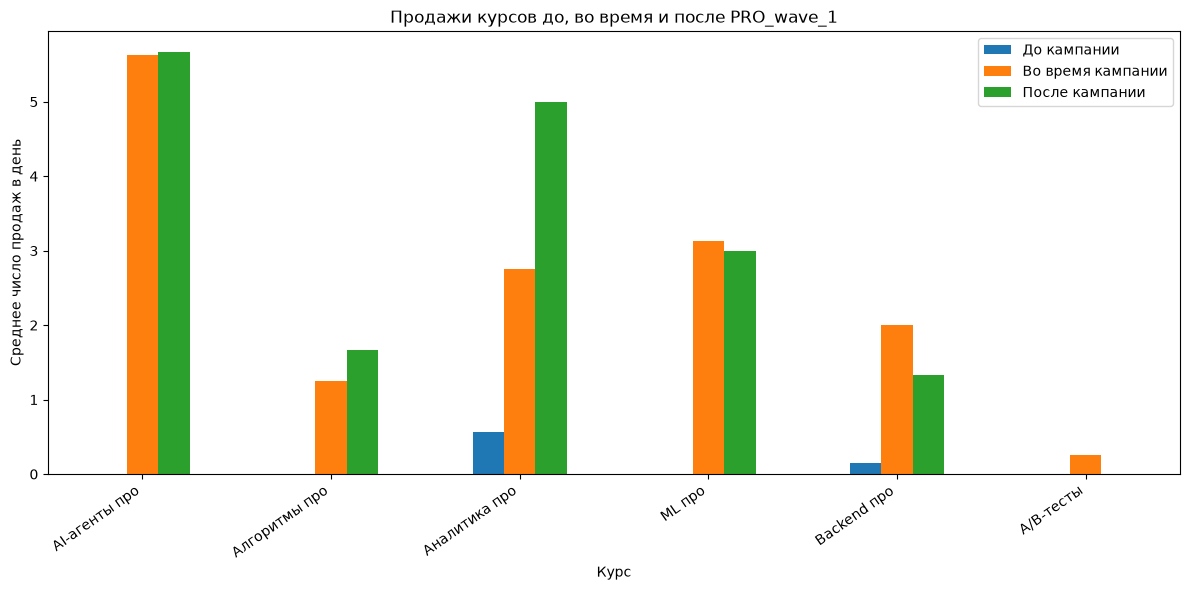

In [86]:
plot_data = (
    wave_results[
        wave_results["wave_id"] == "PRO_wave_1"
    ]
    .set_index("course")[
        [
            "before_per_day",
            "during_per_day",
            "after_per_day"
        ]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Продажи курсов до, во время и после PRO_wave_1")
plt.xlabel("Курс")
plt.ylabel("Среднее число продаж в день")
plt.xticks(rotation=35, ha="right")
plt.legend([
    "До кампании",
    "Во время кампании",
    "После кампании"
])
plt.tight_layout()
plt.show()

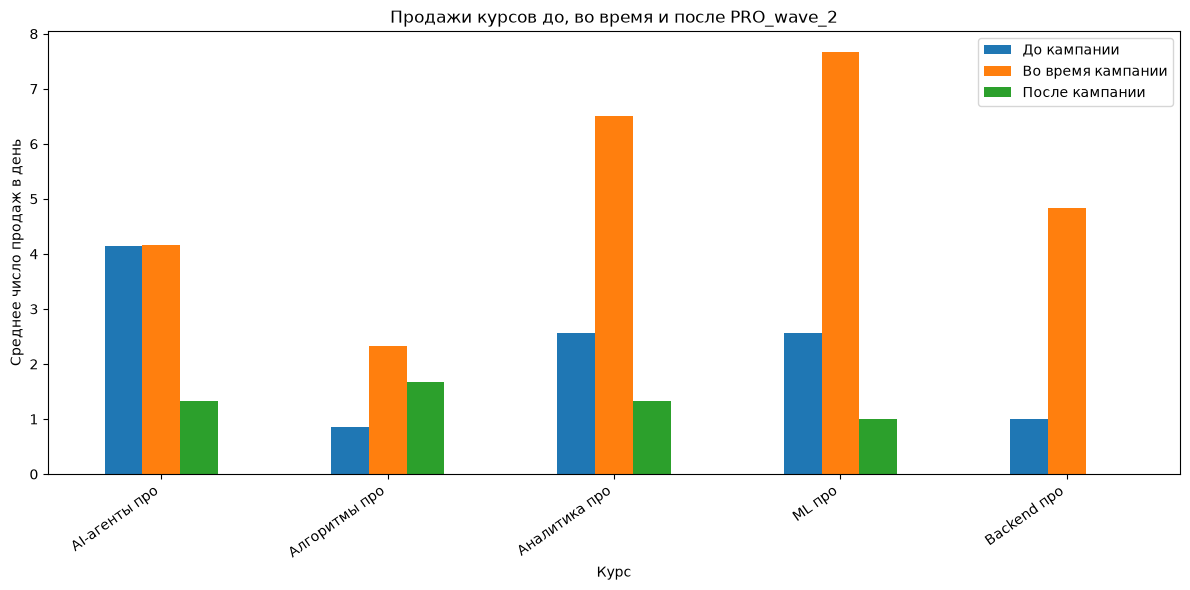

In [87]:
plot_data = (
    wave_results[
        wave_results["wave_id"] == "PRO_wave_2"
    ]
    .set_index("course")[
        [
            "before_per_day",
            "during_per_day",
            "after_per_day"
        ]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Продажи курсов до, во время и после PRO_wave_2")
plt.xlabel("Курс")
plt.ylabel("Среднее число продаж в день")
plt.xticks(rotation=35, ha="right")
plt.legend([
    "До кампании",
    "Во время кампании",
    "После кампании"
])
plt.tight_layout()
plt.show()

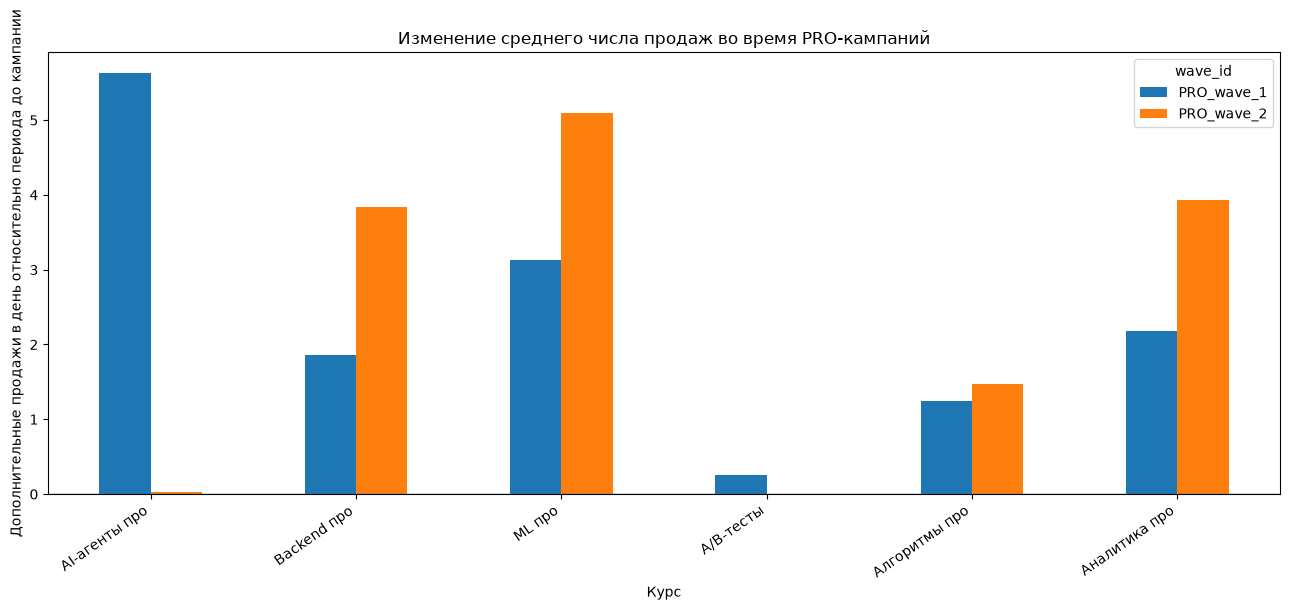

In [88]:
uplift_plot = (
    wave_results[
        [
            "wave_id",
            "course",
            "delta_during"
        ]
    ]
    .pivot(
        index="course",
        columns="wave_id",
        values="delta_during"
    )
)

uplift_plot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Изменение среднего числа продаж во время PRO-кампаний")
plt.xlabel("Курс")
plt.ylabel("Дополнительные продажи в день относительно периода до кампании")
plt.xticks(rotation=35, ha="right")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [89]:
summary = wave_results[
    [
        "wave_id",
        "course",
        "before_per_day",
        "during_per_day",
        "after_per_day",
        "delta_during",
        "uplift_during_pct"
    ]
].copy()

summary = summary.sort_values(
    ["wave_id", "delta_during"],
    ascending=[True, False]
)

summary

,wave_id,course,before_per_day,during_per_day,after_per_day,delta_during,uplift_during_pct
0,PRO_wave_1,AI-агенты про,0.00,5.62,5.67,5.62,NaN
3,PRO_wave_1,ML про,0.00,3.12,3.00,3.12,NaN
2,PRO_wave_1,Аналитика про,0.57,2.75,5.00,2.18,381.25
4,PRO_wave_1,Backend про,0.14,2.00,1.33,1.86,"1,300.00"
1,PRO_wave_1,Алгоритмы про,0.00,1.25,1.67,1.25,NaN
5,PRO_wave_1,А/В-тесты,0.00,0.25,0.00,0.25,NaN
9,PRO_wave_2,ML про,2.57,7.67,1.00,5.10,198.15
8,PRO_wave_2,Аналитика про,2.57,6.50,1.33,3.93,152.78
10,PRO_wave_2,Backend про,1.00,4.83,0.00,3.83,383.33
7,PRO_wave_2,Алгоритмы про,0.86,2.33,1.67,1.48,172.22


## Выводы по маркетинговым волнам PRO

Анализ на уровне отдельных продуктов показывает, что реакция курсов
на одну и ту же маркетинговую волну заметно различается.

Во время первой PRO-волны 22–29 августа наиболее заметный рост
наблюдался у AI-агентов, ML и Аналитики PRO.
Для AI-агентов и ML продажи до начала волны практически отсутствовали,
но во время продвижения достигли в среднем 5.62 и 3.12 покупки в день соответственно.

Во время второй PRO-волны 2–7 сентября наиболее сильный абсолютный рост
наблюдался у ML PRO, Backend PRO и Аналитики PRO.
Например, продажи ML PRO выросли в среднем с 2.57 до 7.67 покупки в день,
Backend PRO — с 1.00 до 4.83, Аналитики PRO — с 2.57 до 6.50.

Таким образом, анализ конкретных продуктов показывает более неоднородную
картину, чем усреднение всех курсов относительно маркетингового события:
одни продукты реагируют на кампанию существенно сильнее других.

Полученные изменения следует интерпретировать как временную связь,
а не как доказанный причинный эффект маркетинга.

In [91]:
START_WAVE = "START_wave_5"

start_wave = wave_course[
    wave_course["wave_id"] == START_WAVE
].copy()

start_results = []

for _, row in start_wave.iterrows():

    course = row["course"]
    start = row["wave_start"]
    end = row["wave_end"]

    course_sales = sales_daily[
        sales_daily["course"] == course
    ]

    before = course_sales[
        (course_sales["date"] >= start - pd.Timedelta(days=3))
        & (course_sales["date"] < start)
    ]

    during = course_sales[
        (course_sales["date"] >= start)
        & (course_sales["date"] <= end)
    ]

    after = course_sales[
        (course_sales["date"] > end)
        & (course_sales["date"] <= end + pd.Timedelta(days=3))
    ]

    start_results.append({
        "course": course,
        "before_per_day": before["purchases"].mean(),
        "during_per_day": during["purchases"].mean(),
        "after_per_day": after["purchases"].mean(),
    })

start_results = pd.DataFrame(start_results)

start_results["delta_during"] = (
    start_results["during_per_day"]
    - start_results["before_per_day"]
)

start_results

,course,before_per_day,during_per_day,after_per_day,delta_during
0,Аналитика старт,0.00,11.67,2.00,11.67
1,Алгоритмы старт,0.00,16.33,2.33,16.33
2,Backend старт,1.00,7.33,0.00,6.33
3,ML старт,1.00,11.00,4.00,10.00


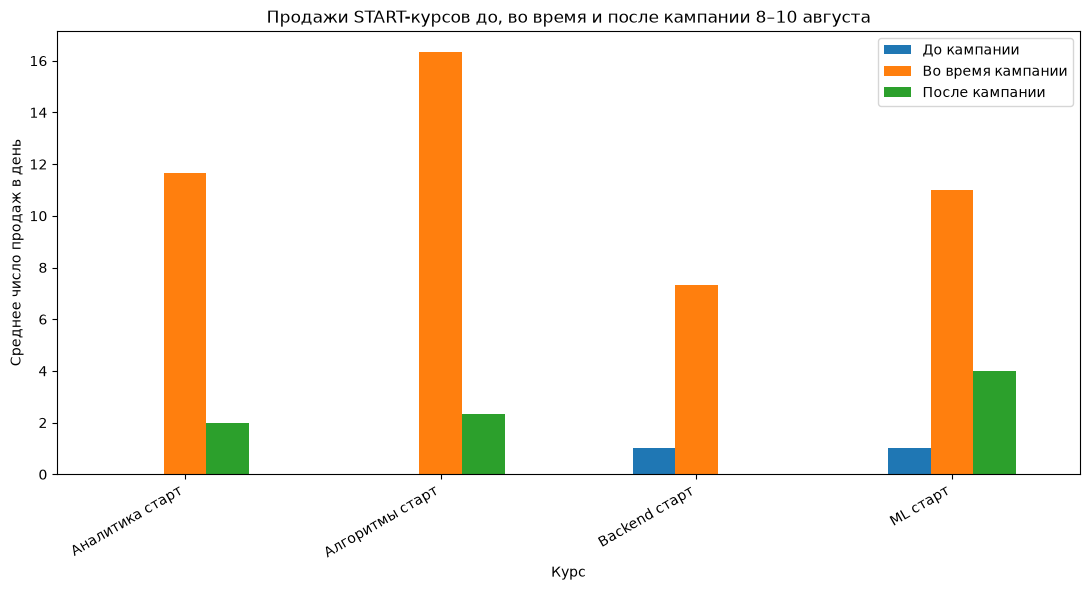

In [92]:
plot_data = (
    start_results
    .set_index("course")[
        [
            "before_per_day",
            "during_per_day",
            "after_per_day"
        ]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Продажи START-курсов до, во время и после кампании 8–10 августа")
plt.xlabel("Курс")
plt.ylabel("Среднее число продаж в день")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend([
    "До кампании",
    "Во время кампании",
    "После кампании"
])

plt.tight_layout()
plt.show()

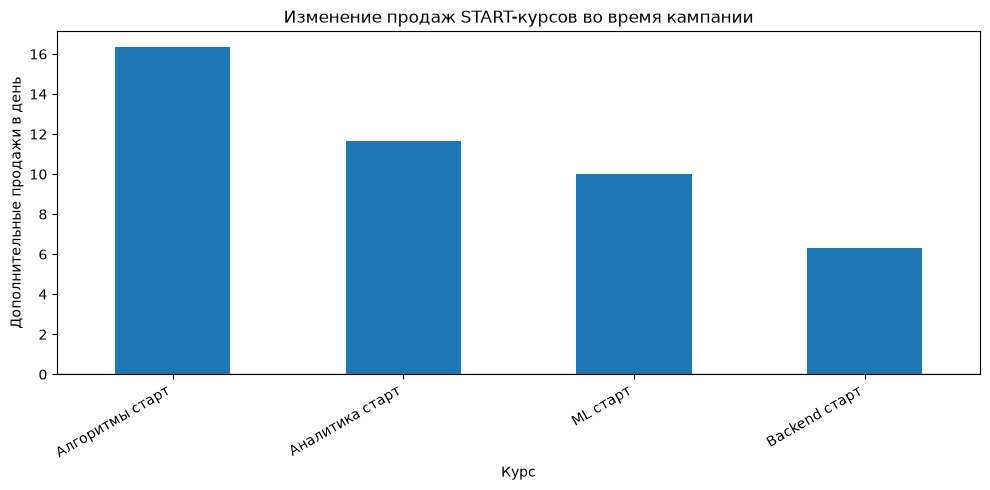

In [93]:
delta_plot = (
    start_results
    .sort_values("delta_during", ascending=False)
    .set_index("course")["delta_during"]
)

delta_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Изменение продаж START-курсов во время кампании")
plt.xlabel("Курс")
plt.ylabel("Дополнительные продажи в день")

plt.axhline(0, linewidth=1)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [94]:
start_results.sort_values(
    "delta_during",
    ascending=False
)

,course,before_per_day,during_per_day,after_per_day,delta_during
1,Алгоритмы старт,0.00,16.33,2.33,16.33
0,Аналитика старт,0.00,11.67,2.00,11.67
3,ML старт,1.00,11.00,4.00,10.00
2,Backend старт,1.00,7.33,0.00,6.33


## Выводы по кампании START

Во время маркетинговой кампании START 8–10 августа наблюдался выраженный рост
продаж всех четырёх курсов линейки.

Наибольший абсолютный рост показал курс «Алгоритмы старт»: среднее число
продаж увеличилось с 0 до 16.33 в день. Для «Аналитики старт» показатель
вырос с 0 до 11.67 продажи в день.

Продажи ML старт увеличились с 1 до 11 продаж в день, а Backend старт —
с 1 до 7.33.

После завершения кампании продажи всех курсов снизились. Это указывает на то,
что основной всплеск спроса был сосредоточен непосредственно в период
активной маркетинговой кампании.

При этом результаты показывают временную связь между маркетинговой активностью
и продажами и не являются доказательством причинного эффекта.